<a href="https://colab.research.google.com/github/Arjunanand717/Deep-learing-/blob/main/EXP2_C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part C: Comparison of Optimization Algorithms

This section will compare the performance of different optimization algorithms (Stochastic Gradient Descent (SGD), Momentum, RMSProp, and Adam) when training an Artificial Neural Network (ANN).

In [1]:
# 1. Setup and Imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Training data shape: (800, 2)
Validation data shape: (200, 2)


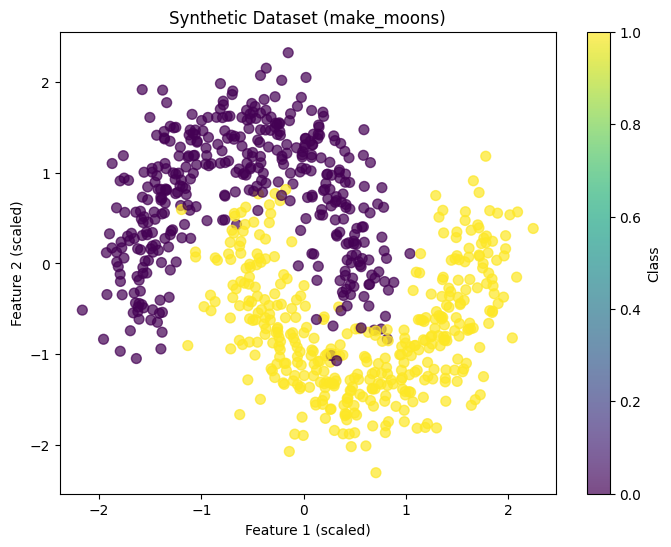

In [2]:
# 2. Data Preparation
# Generate a synthetic dataset (e.g., make_moons for binary classification)
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Validation data shape: {X_val_scaled.shape}")

# Visualize the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap='viridis', s=50, alpha=0.7)
plt.title('Synthetic Dataset (make_moons)')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.colorbar(label='Class')
plt.show()

In [3]:
# 3. Define ANN Model Architecture
def create_ann_model():
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid') # Binary classification
    ])
    return model

# Display model summary
model_template = create_ann_model()
print('Model Architecture:')
model_template.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# 4. Training Function
def train_model_with_optimizer(optimizer_name, optimizer_instance, X_train, y_train, X_val, y_val, epochs=50, batch_size=32):
    print(f"\n--- Training with {optimizer_name} ---")
    model = create_ann_model()
    model.compile(optimizer=optimizer_instance,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),
                        verbose=0) # Set verbose to 0 to suppress output for cleaner logs

    print(f"{optimizer_name} Training complete.")

    # Get final metrics
    train_loss = history.history['loss'][-1]
    train_accuracy = history.history['accuracy'][-1]
    val_loss = history.history['val_loss'][-1]
    val_accuracy = history.history['val_accuracy'][-1]

    print(f"  Final Training Loss: {train_loss:.4f}")
    print(f"  Final Training Accuracy: {train_accuracy:.4f}")
    print(f"  Final Validation Loss: {val_loss:.4f}")
    print(f"  Final Validation Accuracy: {val_accuracy:.4f}")

    return history

## 5. Train with Different Optimizers and Collect History

In [5]:
optimizer_histories = {}
epochs = 50 # You can adjust this for quicker or longer training

# Stochastic Gradient Descent (SGD)
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)
optimizer_histories['SGD'] = train_model_with_optimizer(
    'SGD', sgd_optimizer, X_train_scaled, y_train, X_val_scaled, y_val, epochs=epochs
)

# Momentum
momentum_optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
optimizer_histories['Momentum'] = train_model_with_optimizer(
    'Momentum', momentum_optimizer, X_train_scaled, y_train, X_val_scaled, y_val, epochs=epochs
)

# RMSProp
rmsprop_optimizer = keras.optimizers.RMSprop(learning_rate=0.001)
optimizer_histories['RMSProp'] = train_model_with_optimizer(
    'RMSProp', rmsprop_optimizer, X_train_scaled, y_train, X_val_scaled, y_val, epochs=epochs
)

# Adam
adam_optimizer = keras.optimizers.Adam(learning_rate=0.001)
optimizer_histories['Adam'] = train_model_with_optimizer(
    'Adam', adam_optimizer, X_train_scaled, y_train, X_val_scaled, y_val, epochs=epochs
)

print('\nAll optimizers have completed training.')


--- Training with SGD ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


SGD Training complete.
  Final Training Loss: 0.3082
  Final Training Accuracy: 0.8725
  Final Validation Loss: 0.2872
  Final Validation Accuracy: 0.8750

--- Training with Momentum ---
Momentum Training complete.
  Final Training Loss: 0.1177
  Final Training Accuracy: 0.9613
  Final Validation Loss: 0.0681
  Final Validation Accuracy: 0.9750

--- Training with RMSProp ---
RMSProp Training complete.
  Final Training Loss: 0.1109
  Final Training Accuracy: 0.9588
  Final Validation Loss: 0.0630
  Final Validation Accuracy: 0.9800

--- Training with Adam ---
Adam Training complete.
  Final Training Loss: 0.1097
  Final Training Accuracy: 0.9650
  Final Validation Loss: 0.0657
  Final Validation Accuracy: 0.9800

All optimizers have completed training.


## 6. Visualize Training Results

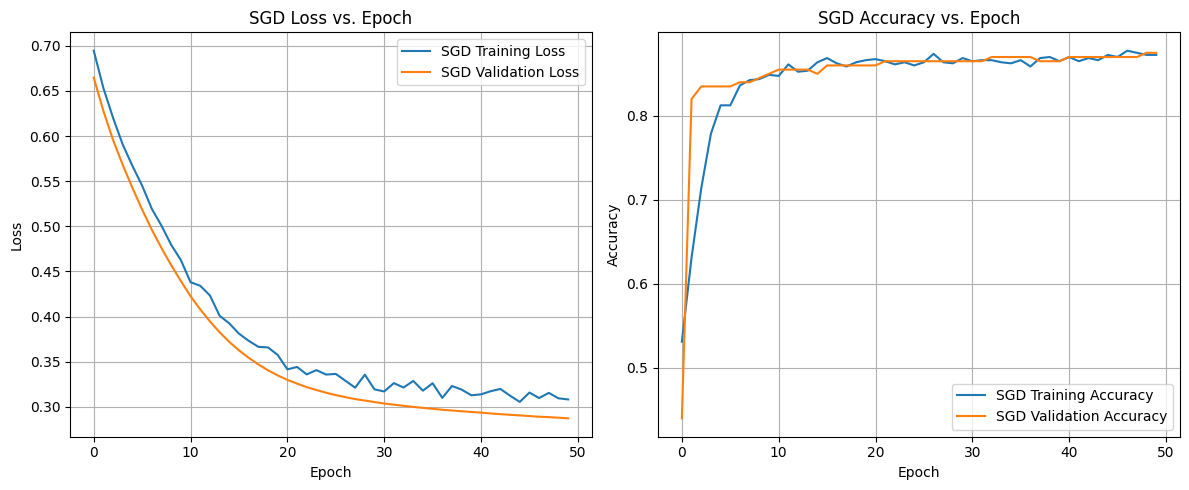

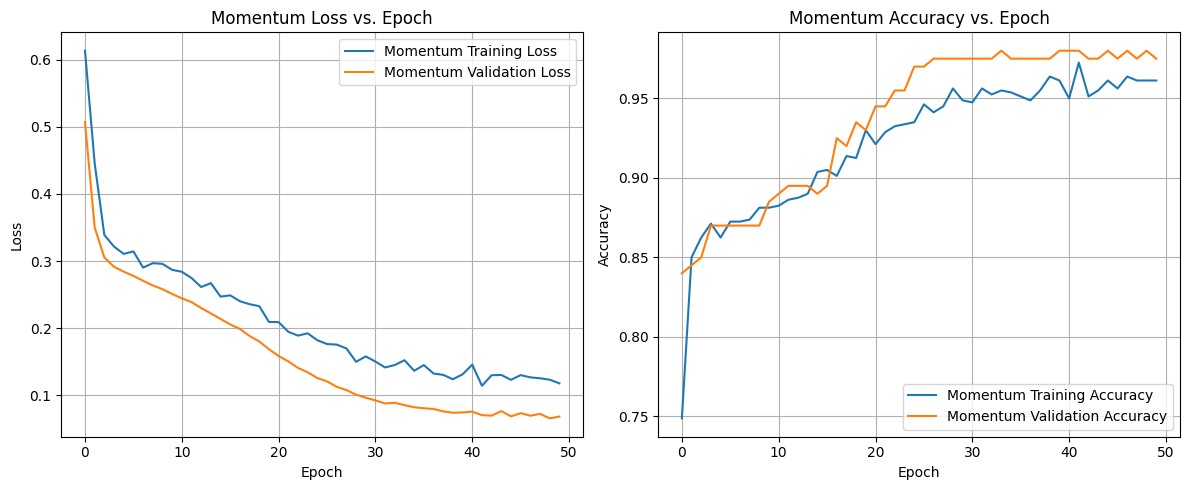

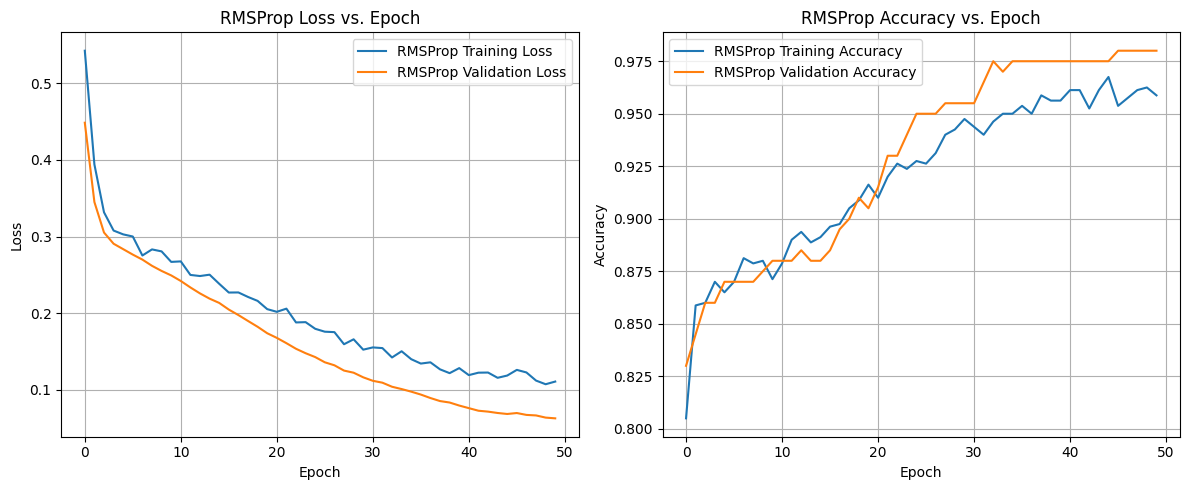

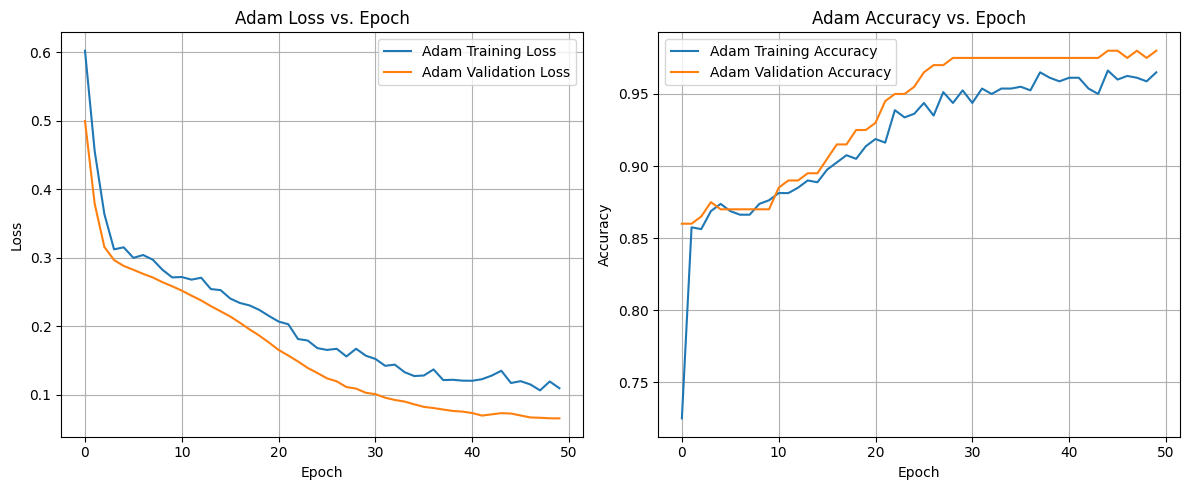

In [6]:
def plot_history(history, optimizer_name):
    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label=f'{optimizer_name} Training Loss')
    plt.plot(history.history['val_loss'], label=f'{optimizer_name} Validation Loss')
    plt.title(f'{optimizer_name} Loss vs. Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label=f'{optimizer_name} Training Accuracy')
    plt.plot(history.history['val_accuracy'], label=f'{optimizer_name} Validation Accuracy')
    plt.title(f'{optimizer_name} Accuracy vs. Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Plot for each optimizer
for optimizer_name, history in optimizer_histories.items():
    plot_history(history, optimizer_name)

## 7. Compare and Discuss Results

Based on the training histories and visualizations, we can compare the optimizers across the following metrics:

*   **Training Loss & Validation Loss**: Observe the curves to see how quickly the loss decreases and if there's a significant gap between training and validation loss (indicating overfitting).
*   **Convergence Speed**: Which optimizer reaches a low loss/high accuracy state faster?
*   **Final Training Accuracy & Final Validation Accuracy**: Compare the ultimate performance on both training and unseen data.

### Discussion Points:

1.  **SGD**: Typically slower to converge and can oscillate, but can find good minima. Without momentum, it might struggle with flat regions or saddle points.
2.  **Momentum**: Introduces a 'velocity' term, helping SGD accelerate in the right direction and overcome small local minima or flat regions. Should converge faster and more smoothly than plain SGD.
3.  **RMSProp**: Adapts the learning rate for each parameter, scaling it by the root mean square of recent gradients. This helps handle sparse gradients and can speed up training on non-stationary objectives.
4.  **Adam**: Combines the best aspects of Momentum and RMSProp. It uses adaptive learning rates for each parameter (like RMSProp) and also incorporates momentum. It's often the default choice due to its robustness and generally fast convergence.

By examining the plots and final metrics, we can identify which optimizer achieved the best balance of speed, stability, and generalization for this specific task and model architecture.